In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
daily_rainfall = pd.read_csv('customized_daily_rainfall_data.csv')
daily_rainfall.head()

,StationIndex,Station,Year,Month,Day,Rainfall
0,1,Dhaka,1970,1,1,0
1,1,Dhaka,1970,1,2,0
2,1,Dhaka,1970,1,3,0
3,1,Dhaka,1970,1,4,0
4,1,Dhaka,1970,1,5,0


In [4]:
daily_rainfall.head(40)

,StationIndex,Station,Year,Month,Day,Rainfall
0,1,Dhaka,1970,1,1,0
1,1,Dhaka,1970,1,2,0
2,1,Dhaka,1970,1,3,0
3,1,Dhaka,1970,1,4,0
4,1,Dhaka,1970,1,5,0
5,1,Dhaka,1970,1,6,0
6,1,Dhaka,1970,1,7,0
7,1,Dhaka,1970,1,8,0
8,1,Dhaka,1970,1,9,0
9,1,Dhaka,1970,1,10,0


In [6]:
monthly_rainfall = pd.read_csv('data_monthly_rainfall.csv')
monthly_rainfall.head()

,Year,Station,Month,Rainfall,StationIndex
0,1970,Barisal,1,0,2
1,1970,Barisal,2,24,2
2,1970,Barisal,3,5,2
3,1970,Barisal,4,91,2
4,1970,Barisal,5,124,2


In [7]:
monthly_rainfall.shape

(16755, 5)

In [12]:
# Get time by aggregating the data by month and year
monthly_rainfall['Time'] = monthly_rainfall['Year'].astype(str) + '-' + monthly_rainfall['Month'].astype(str)
monthly_rainfall['Time'] = pd.to_datetime(monthly_rainfall['Time'], format='%Y-%m')
monthly_rainfall.head()

,Year,Station,Month,Rainfall,StationIndex,Time
0,1970,Barisal,1,0,2,1970-01-01
1,1970,Barisal,2,24,2,1970-02-01
2,1970,Barisal,3,5,2,1970-03-01
3,1970,Barisal,4,91,2,1970-04-01
4,1970,Barisal,5,124,2,1970-05-01


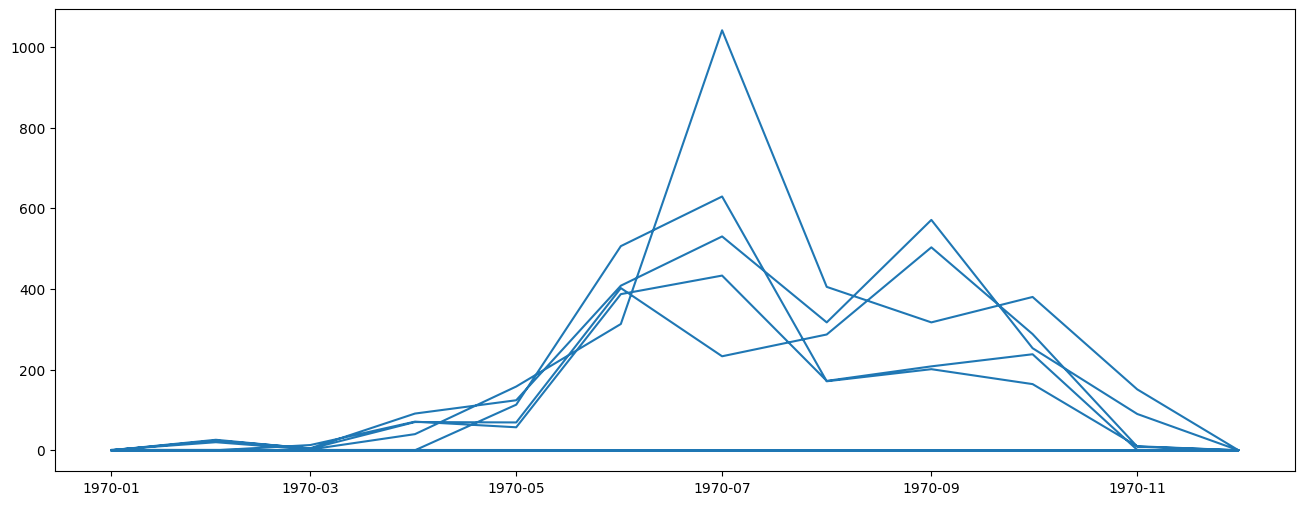

In [14]:
plt.figure(figsize=(16, 6))
plt.plot(monthly_rainfall['Time'][:12*5], monthly_rainfall["Rainfall"][:12*5])

In [20]:
monthly_rainfall.Station.unique().shape

(33,)

In [21]:
monthly_rainfall.StationIndex.unique().shape

(33,)

In [24]:
# now create seperate dataframes for each station and save them as csv files under the the folder name "monthly_station_data"
for station in monthly_rainfall['Station'].unique():
    station_data = monthly_rainfall[monthly_rainfall['Station'] == station]
    station_data.to_csv(f'monthly_station_data/{station}.csv', index=False)

In [25]:
tangail_monthly_rainfall = pd.read_csv('monthly_station_data/Tangail.csv')
tangail_monthly_rainfall.head()

,Year,Station,Month,Rainfall,StationIndex,Time
0,1987,Tangail,1,0,32,1987-01-01
1,1987,Tangail,2,18,32,1987-02-01
2,1987,Tangail,3,0,32,1987-03-01
3,1987,Tangail,4,302,32,1987-04-01
4,1987,Tangail,5,108,32,1987-05-01


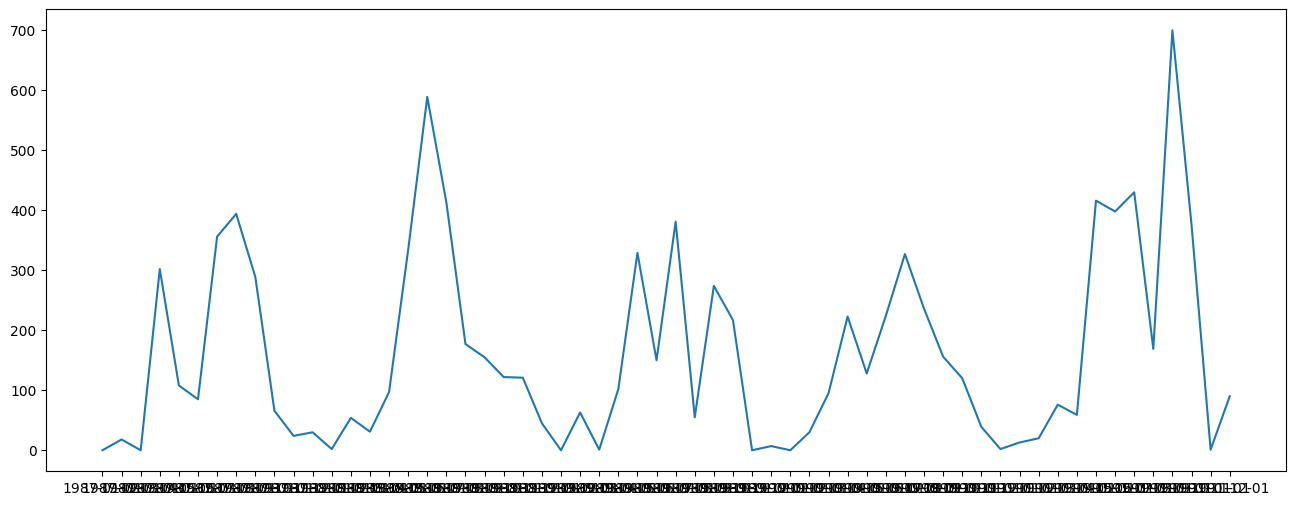

In [26]:
plt.figure(figsize=(16, 6))
plt.plot(tangail_monthly_rainfall['Time'][:12*5], tangail_monthly_rainfall["Rainfall"][:12*5])

In [27]:
# i want to make a all in one csv cols will be year, month, time, station_1_name(value will be rainfall), station_2_name(value will be rainfall), station_3_name(value will be rainfall) and so on for all the stations.
for station in monthly_rainfall['Station'].unique():
    station_data = monthly_rainfall[monthly_rainfall['Station'] == station]
    station_data = station_data[['Year', 'Month', 'Time', 'Rainfall']]
    station_data.rename(columns={'Rainfall': station}, inplace=True)
    if station == monthly_rainfall['Station'].unique()[0]:
        all_stations_monthly_data = station_data
    else:
        all_stations_monthly_data = pd.merge(all_stations_monthly_data, station_data, on=['Year', 'Month', 'Time'], how='outer')

all_stations_monthly_data.to_csv('all_stations_monthly_data.csv', index=False)

In [ ]:
all_stations_monthly_data.head()

,Year,Month,Time,Barisal,Bhola,Bogra,Chandpur,Chittagong,Comilla,CoxsBazar,...,Patuakhali,Feni,Khepupara,Madaripur,Sitakunda,Teknaf,Kutubdia,Tangail,Mongla,Ambagan_ctg
0,1970,1,1970-01-01,0,0.0,0.0,0.0,1.0,20.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1970,2,1970-02-01,24,26.0,0.0,0.0,20.0,9.0,40,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1970,3,1970-03-01,5,4.0,0.0,13.0,2.0,63.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1970,4,1970-04-01,91,70.0,0.0,71.0,40.0,134.0,69,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1970,5,1970-05-01,124,69.0,113.0,57.0,158.0,187.0,331,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
nan_count = all_stations_monthly_data.isna().sum().sum()
print(f"Number of NaN values in the dataset: {nan_count}")

Number of NaN values in the dataset: 1933


In [30]:
# nan found col name and row index
nan_locations = np.where(all_stations_monthly_data.isna())
nan_rows = nan_locations[0]
nan_cols = nan_locations[1]

In [31]:
nan_info = [(all_stations_monthly_data.index[row], all_stations_monthly_data.columns[col]) for row, col in zip(nan_rows, nan_cols)]
nan_info_df = pd.DataFrame(nan_info, columns=['Row Index', 'Column Name'])

In [33]:
nan_info_df.head()

,Row Index,Column Name
0,0,Rajshahi
1,0,Patuakhali
2,0,Feni
3,0,Khepupara
4,0,Madaripur


In [35]:
# per column nan count
nan_count_per_column = all_stations_monthly_data.isna().sum()
nan_count_per_column_df = pd.DataFrame(nan_count_per_column, columns=['NaN Count'])
nan_count_per_column_df

,NaN Count
Year,0
Month,0
Time,0
Barisal,0
Bhola,12
Bogra,13
Chandpur,50
Chittagong,72
Comilla,13
CoxsBazar,0


In [38]:
# found cols with nan values
cols_with_nan = nan_count_per_column[nan_count_per_column > 0].index.tolist()
print(f"Columns with NaN values: {cols_with_nan}")

# create a seperate csv files for all column with nan values count 0
non_nan_columns = all_stations_monthly_data[cols_with_nan].dropna(axis=0, how='any')
non_nan_columns.to_csv("non_nan_columns.csv", index=False)

Columns with NaN values: ['Bhola', 'Bogra', 'Chandpur', 'Chittagong', 'Comilla', 'Dhaka', 'Dinajpur', 'Hatiya', 'Jessore', 'Khulna', 'M.court', 'Mymensingh', 'Rangpur', 'Sandwip', 'Srimangal', 'Sylhet', 'Rajshahi', 'Patuakhali', 'Feni', 'Khepupara', 'Madaripur', 'Sitakunda', 'Teknaf', 'Kutubdia', 'Tangail', 'Mongla', 'Ambagan_ctg']


In [39]:
non_nan_columns.columns

Index(['Bhola', 'Bogra', 'Chandpur', 'Chittagong', 'Comilla', 'Dhaka',
       'Dinajpur', 'Hatiya', 'Jessore', 'Khulna', 'M.court', 'Mymensingh',
       'Rangpur', 'Sandwip', 'Srimangal', 'Sylhet', 'Rajshahi', 'Patuakhali',
       'Feni', 'Khepupara', 'Madaripur', 'Sitakunda', 'Teknaf', 'Kutubdia',
       'Tangail', 'Mongla', 'Ambagan_ctg'],
      dtype='object')